# 18 — Ce qu'il faut demander au titre de l'article 40

Le [notebook 17](17_rang_servi.ipynb) s'est terminé sur un constat : aucun jeu public ne porte à
la fois le **rang servi** et une **étiquette de point de vue interprétable**. Il reste une voie,
prévue par l'article 40 du *Digital Services Act* et rendue opérationnelle par le règlement
délégué (UE) 2025/2050, entré en vigueur le 29 octobre 2025 : **demander la donnée**.

Une demande n'est recevable que si elle est **nécessaire et proportionnée** — article 40(8)(e)
du DSA, article 8(d) du règlement délégué. « Donnez-nous vos journaux » n'est ni l'un ni
l'autre : cela réclame des données personnelles dont l'analyse n'a aucun besoin, et cela offre à
la plateforme le motif de refus le plus facile, la sécurité du service et le secret des affaires
(article 40(5)).

Ce notebook fait le travail inverse. Il définit les **quatre tableaux agrégés** dont les mesures
de ce dépôt ont réellement besoin, et vérifie qu'elles s'y retrouvent **à l'identique**. La
demande cesse alors d'être un accès à négocier pour devenir un livrable spécifié.

**Ce que ce notebook établit :**

* les quatre mesures qui décident de tout — test d'échangeabilité, sévérité $\eta$, diversité
  aveugle au rang, diversité consciente du rang — se recalculent **exactement** depuis des
  tableaux qui ne contiennent **aucune ligne par lecteur** ;
* ce qui est demandé pèse **quelques milliers de lignes** là où le journal brut en compte des
  millions : sur Baidu-ULTR, 5 543 lignes pour 524 164 documents servis, soit un rapport de 95 ;
* le **seuil de confidentialité n'est pas neutre** — supprimer les cellules de moins de 20
  impressions déplace la sévérité estimée de 1,10 à 1,40, soit 27 % ;
* et le tableau 4 suffit à constater l'**enterrement**, la grandeur de contrôle que le
  [mémorandum](../docs/memorandum.md) demande d'imposer.

La demande elle-même, rédigée et prête à déposer, est à
[l'article 40](../docs/article-40.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.aggregates import (
    aggregate,
    blind_distribution,
    exchangeability_from,
    served_distribution,
    severity_from,
    suppression_sensitivity,
)
from ide.exposure import SOURCES, load_digest as load_exposure_digest
from ide.gaming import canonical_positions, position_entropy
from ide.logs import Impressions, exchangeability_test
from ide.mind import load_digest as load_mind_digest
from ide.offpolicy import estimate_position_bias
from ide.plotting import PALETTE, save_figure, use_project_style
from ide.radio import rank_weights
from ide.ranking import optimal_ranking_under

use_project_style()

exposure = load_exposure_digest()
baidu = exposure.impressions("baidu")
mind = load_mind_digest().impressions("train")

print(f"Baidu-ULTR : {baidu.feed_count} sessions, {baidu.served} documents servis")
print(f"MIND       : {mind.feed_count} fils, {mind.served} contenus servis")

Baidu-ULTR : 64200 sessions, 524164 documents servis
MIND       : 156965 fils, 5843444 contenus servis


## 1. Les quatre tableaux

| | Tableau | Clé | Valeur |
|---|---|---|---|
| 1 | profils de fils | (profil de rangs, nombre de clics du fil) | nombre de fils |
| 2 | clics par rang | (profil de rangs, nombre de clics du fil, rang) | nombre de clics |
| 3 | cellules | (contenu, rang) *et propension si connue* | impressions, clics |
| 4 | exposition | (rang, point de vue déclaré) | impressions |

Le **profil de rangs** est la liste des rangs qu'un fil occupe. L'indexer par la seule longueur
serait plus court et **faux** dès qu'une page saute des rangs — c'est la correction qu'a imposée
Baidu-ULTR. Le **nombre de clics du fil**, second index des tableaux 1 et 2, n'est pas un
ornement non plus : sans lui, les fils dont *tout* a été cliqué ne peuvent pas être écartés, et
le test se décale.

Aucune ligne ne désigne un lecteur. Un fil n'y figure que par sa forme et par le nombre de clics
qu'il a reçus.

In [2]:
# Le condensé versionné ne retient pas l'identité des contenus ligne à ligne ; les tableaux 1
# et 2 n'en dépendent pas, et c'est d'eux seuls que vient le test d'échangeabilité.
def with_placeholder(impressions):
    return Impressions(items=impressions.ranks, ranks=impressions.ranks,
                       clicks=impressions.clicks, feeds=impressions.feeds,
                       feed_lengths=impressions.feed_lengths)


requests = {name: aggregate(with_placeholder(impressions))
            for name, impressions in (("Baidu-ULTR", baidu), ("MIND", mind))}

raw_bytes = {"Baidu-ULTR": SOURCES["baidu"][1],
             "MIND": 92_019_716 + 42_838_544}

print(f"{'journal':12s} {'lignes servies':>15s} {'lignes demandées':>18s} {'rapport':>9s}"
      f" {'profils':>9s}")
print("-" * 68)
for name, request in requests.items():
    served = baidu.served if name == "Baidu-ULTR" else mind.served
    profiles = request.profile_offsets.size - 1
    print(f"{name:12s} {served:15d} {request.rows:18d} {served / request.rows:9.1f}"
          f" {profiles:9d}")

journal       lignes servies   lignes demandées   rapport   profils
--------------------------------------------------------------------
Baidu-ULTR            524164               5543      94.6      1007
MIND                 5843444              57906     100.9       296


## 2. La preuve que cela suffit

Quatre mesures, calculées deux fois : directement sur le journal, puis sur les seuls tableaux
agrégés. L'écart doit être **nul**, pas petit.

In [3]:
print("Test d'échangeabilité — le contrôle qui décide si un journal est corrigible\n")
print(f"{'journal':12s} {'direct':>14s} {'depuis les tableaux':>21s} {'écart':>12s}")
print("-" * 62)
checks = {}
for name, impressions in (("Baidu-ULTR", baidu), ("MIND", mind)):
    direct = exchangeability_test(impressions)
    from_tables = exchangeability_from(requests[name])
    checks[name] = (direct.deviation, from_tables.deviation)
    print(f"{name:12s} {direct.deviation:14.6f} {from_tables.deviation:21.6f}"
          f" {abs(direct.deviation - from_tables.deviation):12.2e}")

Test d'échangeabilité — le contrôle qui décide si un journal est corrigible

journal              direct   depuis les tableaux        écart
--------------------------------------------------------------
Baidu-ULTR      -205.719247           -205.719247     2.84e-13
MIND               0.115856              0.115856     3.29e-12


In [4]:
items, ranks, clicks = exposure.rows("baidu")
cells = Impressions(items=items, ranks=ranks, clicks=clicks,
                    feeds=np.arange(items.size), feed_lengths=np.ones(items.size, dtype=np.int64))
cell_request = aggregate(cells)

direct_severity = estimate_position_bias(items, ranks, clicks, minimum_impressions=5)
table_severity = severity_from(cell_request, minimum_impressions=5)

print("Sévérité du biais de position, sur Baidu-ULTR\n")
print(f"  directe            : {direct_severity.severity:.6f} ± "
      f"{direct_severity.standard_error:.6f}")
print(f"  depuis le tableau 3: {table_severity.severity:.6f} ± "
      f"{table_severity.standard_error:.6f}")
print(f"  écart              : {abs(direct_severity.severity - table_severity.severity):.2e}")
print(f"  lignes du tableau 3: {cell_request.cell_items.size}")

Sévérité du biais de position, sur Baidu-ULTR

  directe            : 1.098729 ± 0.088996
  depuis le tableau 3: 1.098729 ± 0.088996
  écart              : 0.00e+00
  lignes du tableau 3: 1292


## 3. Ce que le tableau 4 permet de constater : l'enterrement

Le [mémorandum](../docs/memorandum.md) demande d'imposer une mesure de diversité **consciente du
rang**, et de contrôler l'écart avec la mesure aveugle — l'écart d'**enterrement**, qui vaut zéro
pour une plateforme qui ne relègue pas.

Cet écart se calcule sur le seul tableau 4. Voici **trois fils de composition identique** :
celui que le [rang adverse](../docs/rang-adverse.md) a montré optimal sous un plancher aveugle,
le même entrelacé, et le même retourné.

In [5]:
VIEWPOINTS, SLOTS = 4, 8
CATALOGUE = canonical_positions(VIEWPOINTS)
RELEVANCE = np.array([0.90, 0.45, 0.25, 0.15])

burying = optimal_ranking_under(
    lambda weights: position_entropy(weights, CATALOGUE, CATALOGUE),
    RELEVANCE, SLOTS, 0.70, rank_aware=False,
)
buried_feed = burying.assignment
reversed_feed = buried_feed[::-1]
# Entrelacement : la même composition, répartie le plus régulièrement possible sur les rangs.
minority = [value for value in buried_feed if value != 0]
interleaved = []
remaining = list(minority)
for slot in range(SLOTS):
    if remaining and slot % 2 == 1:
        interleaved.append(remaining.pop(0))
    else:
        interleaved.append(0)
interleaved = np.asarray(interleaved + remaining, dtype=int)[:SLOTS]

for label, feed in (("conforme au plancher aveugle", buried_feed),
                    ("entrelacé", interleaved),
                    ("retourné", reversed_feed)):
    print(f"fil {label:30s} : {''.join(str(v) for v in feed)}")
print()

REPEATS = 500
comparison = {}
for label, assignment in (("enterré", buried_feed), ("entrelacé", interleaved),
                          ("retourné", reversed_feed)):
    categories = np.tile(assignment, REPEATS)
    impressions = Impressions(
        items=categories.astype(np.int64),
        ranks=np.tile(np.arange(1, SLOTS + 1), REPEATS).astype(np.int64),
        clicks=np.zeros(categories.size),
        feeds=np.repeat(np.arange(REPEATS), SLOTS).astype(np.int64),
        feed_lengths=np.full(REPEATS, SLOTS, dtype=np.int64),
    )
    request = aggregate(impressions, categories=categories)
    blind = blind_distribution(request)
    served = served_distribution(request)
    comparison[label] = (blind, served)
    minority_share = 1.0 - served[0]
    print(f"{label:12s} composition {np.round(blind, 3)}  exposée {np.round(served, 3)}")
    print(f"{'':12s} écart composition/exposition {0.5 * np.abs(blind - served).sum():.3f}"
          f"   part d'attention aux points de vue minoritaires {minority_share:.3f}")

fil conforme au plancher aveugle   : 00000123
fil entrelacé                      : 01020300
fil retourné                       : 32100000

enterré      composition [0.625 0.125 0.125 0.125]  exposée [0.84  0.061 0.053 0.046]
             écart composition/exposition 0.215   part d'attention aux points de vue minoritaires 0.160
entrelacé    composition [0.625 0.125 0.125 0.125]  exposée [0.663 0.184 0.092 0.061]
             écart composition/exposition 0.097   part d'attention aux points de vue minoritaires 0.337
retourné     composition [0.625 0.125 0.125 0.125]  exposée [0.325 0.123 0.184 0.368]
             écart composition/exposition 0.302   part d'attention aux points de vue minoritaires 0.675


Les trois fils ont **la même composition** — même nombre de contenus de chaque point de vue — et
trois expositions différentes. Un régulateur qui ne reçoit que le tableau 4 le voit ; un
régulateur qui ne reçoit que la composition ne le voit pas.

L'écart entre composition et exposition **ne vaut pas zéro pour un fil neutre** : avec une remise
en $1/R$, seule une répartition parfaitement uniforme des points de vue sur les rangs
l'annulerait. Ce qu'il sépare, ce sont des **ordres**, à composition constante — et la grandeur
directement lisible est la part d'attention laissée aux points de vue minoritaires : 0,375 de la
composition, contre ce que chaque ordre en expose réellement.

## 4. Ce que le seuil de confidentialité coûte

Supprimer les lignes de faible effectif protège les lecteurs. Ce n'est pas gratuit : les
cellules rares sont aussi celles des rangs profonds, dont l'estimation de $\eta$ tire
l'essentiel de son information.

In [6]:
sensitivity = suppression_sensitivity(cells, thresholds=(0, 5, 20, 50, 100))

print(f"{'seuil':>6s} {'sévérité':>10s} {'erreur type':>12s} {'lignes demandées':>18s}")
print("-" * 50)
for threshold, (severity, error, rows) in sensitivity.items():
    print(f"{threshold:6d} {severity:10.3f} {error:12.3f} {rows:18d}")

reference = sensitivity[5][0]
print(f"\nDe 5 à 20 impressions, la sévérité passe de {sensitivity[5][0]:.2f} à "
      f"{sensitivity[20][0]:.2f}, soit {100 * (sensitivity[20][0] / reference - 1):+.0f} %.")
print("Le seuil doit donc être négocié et publié avec le résultat, pas laissé au hasard.")

 seuil   sévérité  erreur type   lignes demandées
--------------------------------------------------
     0      1.099        0.089               1333
     5      1.099        0.089               1331
    20      1.395        0.114                265
    50      1.437        0.152                150
   100      1.374        0.215                 98

De 5 à 20 impressions, la sévérité passe de 1.10 à 1.40, soit +27 %.
Le seuil doit donc être négocié et publié avec le résultat, pas laissé au hasard.


## 5. La figure

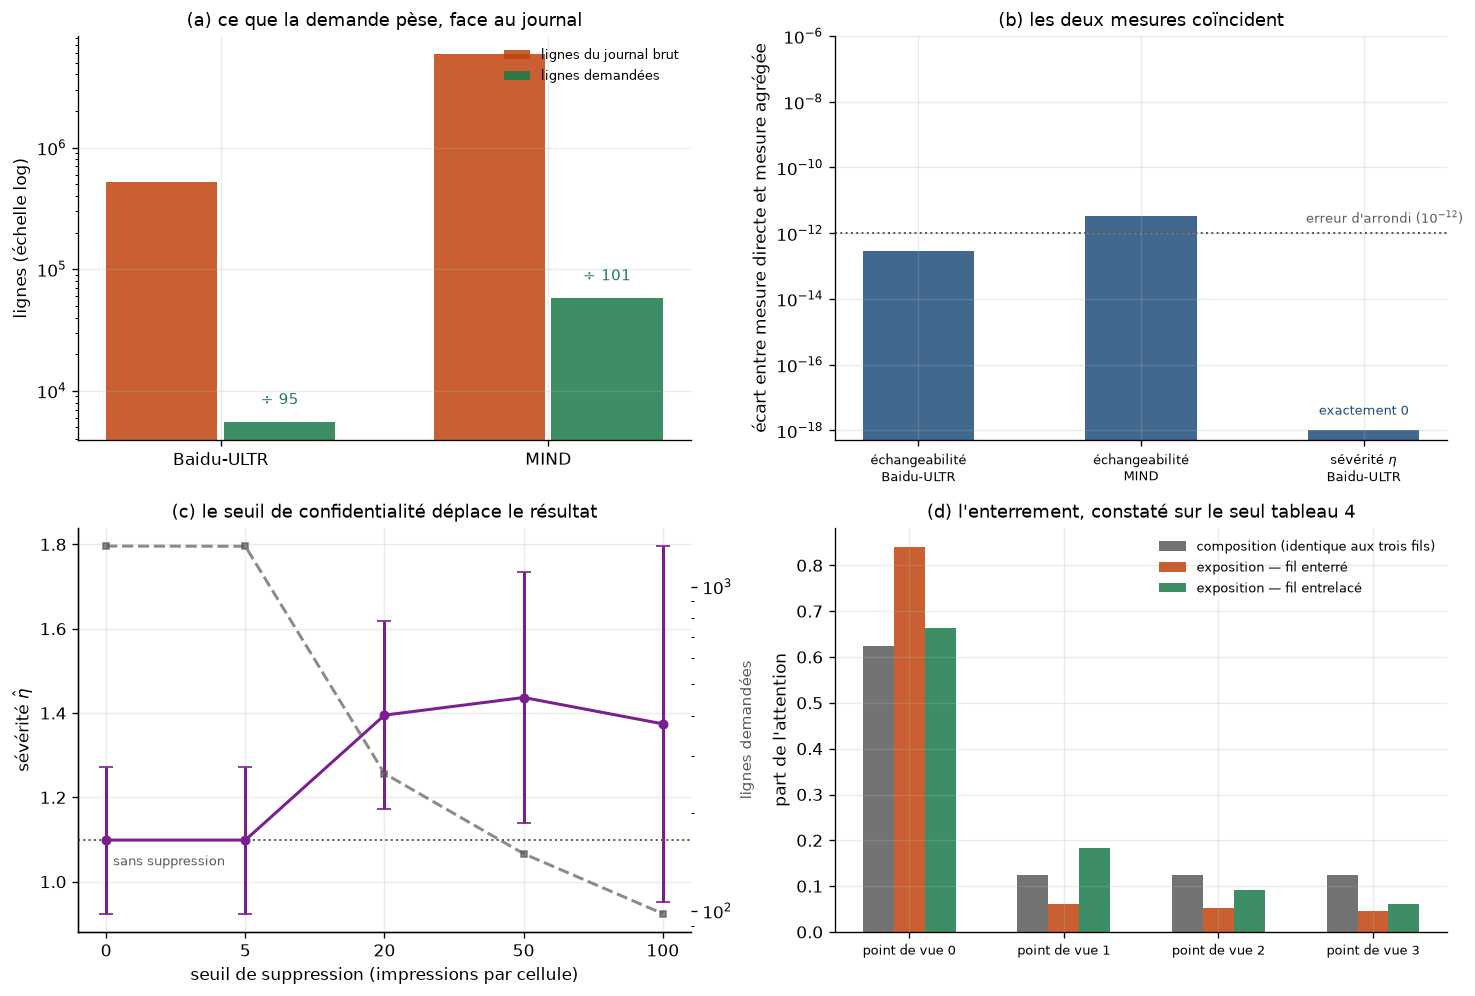

In [7]:
figure, axes = plt.subplots(2, 2, figsize=(12.4, 8.4))

# (a) ce que la demande pèse
ax = axes[0, 0]
names = list(requests)
served_rows = [baidu.served, mind.served]
asked_rows = [requests[name].rows for name in names]
positions = np.arange(len(names))
ax.bar(positions - 0.18, served_rows, width=0.34, color=PALETTE["disorder"], alpha=0.85,
       label="lignes du journal brut")
ax.bar(positions + 0.18, asked_rows, width=0.34, color=PALETTE["remedy"], alpha=0.85,
       label="lignes demandées")
for index, (served, asked) in enumerate(zip(served_rows, asked_rows, strict=True)):
    ax.text(index + 0.18, asked * 1.4, f"÷ {served / asked:.0f}", ha="center", fontsize=9,
            color=PALETTE["remedy"])
ax.set_yscale("log")
ax.set_xticks(positions)
ax.set_xticklabels(names)
ax.set_ylabel("lignes (échelle log)")
ax.set_title("(a) ce que la demande pèse, face au journal")
ax.legend(loc="upper right", fontsize=8)

# (b) l'exactitude
ax = axes[0, 1]
labels = ["échangeabilité\nBaidu-ULTR", "échangeabilité\nMIND", "sévérité $\\eta$\nBaidu-ULTR"]
gaps = [abs(checks["Baidu-ULTR"][0] - checks["Baidu-ULTR"][1]),
        abs(checks["MIND"][0] - checks["MIND"][1]),
        abs(direct_severity.severity - table_severity.severity)]
floor = 1e-18
ax.bar(labels, [max(gap, floor) for gap in gaps], color=PALETTE["order"], alpha=0.85, width=0.5)
ax.axhline(1e-12, color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
ax.text(2.45, 2e-12, "erreur d'arrondi ($10^{-12}$)", fontsize=8, color=PALETTE["neutral"],
        ha="right")
if gaps[2] == 0.0:
    ax.text(2, floor * 3, "exactement 0", fontsize=8, color=PALETTE["order"], ha="center")
ax.set_yscale("log")
ax.set_ylim(floor / 2, 1e-6)
ax.set_ylabel("écart entre mesure directe et mesure agrégée")
ax.set_title("(b) les deux mesures coïncident")
ax.tick_params(axis="x", labelsize=8)

# (c) le seuil de confidentialité
ax = axes[1, 0]
thresholds = np.array(list(sensitivity))
severities = np.array([sensitivity[t][0] for t in thresholds])
errors = np.array([sensitivity[t][1] for t in thresholds])
ax.errorbar(np.arange(thresholds.size), severities, yerr=1.96 * errors, fmt="o-",
            color=PALETTE["field"], markersize=5, capsize=4, label="sévérité estimée")
ax.axhline(severities[0], color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
ax.text(0.05, severities[0] - 0.06, "sans suppression", fontsize=8, color=PALETTE["neutral"])
ax.set_xticks(np.arange(thresholds.size))
ax.set_xticklabels([str(t) for t in thresholds])
ax.set_xlabel("seuil de suppression (impressions par cellule)")
ax.set_ylabel("sévérité $\\hat\\eta$")
ax.set_title("(c) le seuil de confidentialité déplace le résultat")

twin = ax.twinx()
twin.plot(np.arange(thresholds.size), [sensitivity[t][2] for t in thresholds], "s--",
          color=PALETTE["neutral"], markersize=4, alpha=0.7)
twin.set_ylabel("lignes demandées", color=PALETTE["neutral"], fontsize=9)
twin.set_yscale("log")
twin.grid(False)

# (d) l'enterrement, vu depuis le seul tableau 4
ax = axes[1, 1]
width = 0.2
viewpoints = np.arange(VIEWPOINTS)
blind_buried, served_buried = comparison["enterré"]
_, served_honest = comparison["entrelacé"]
ax.bar(viewpoints - width, blind_buried, width=width, color=PALETTE["neutral"], alpha=0.85,
       label="composition (identique aux trois fils)")
ax.bar(viewpoints, served_buried, width=width, color=PALETTE["disorder"], alpha=0.85,
       label="exposition — fil enterré")
ax.bar(viewpoints + width, served_honest, width=width, color=PALETTE["remedy"], alpha=0.85,
       label="exposition — fil entrelacé")
ax.set_xticks(viewpoints)
ax.set_xticklabels([f"point de vue {v}" for v in viewpoints], fontsize=8)
ax.set_ylabel("part de l'attention")
ax.set_title("(d) l'enterrement, constaté sur le seul tableau 4")
ax.legend(loc="upper right", fontsize=8)

save_figure(figure, "fig18_demande_article_40")
plt.show()

## 6. Ce que cette spécification change à la demande

**Elle retire à la plateforme son motif de refus le plus facile.** L'article 40(5) permet de
demander l'amendement d'une requête au motif que la divulgation créerait des vulnérabilités de
sécurité ou révélerait des secrets d'affaires. Des comptages par rang et par point de vue
déclaré ne révèlent ni le classement, ni ses paramètres, ni les contenus : ils disent **ce qui a
été exposé**, pas comment la plateforme a décidé de l'exposer.

**Elle rend la proportionnalité vérifiable.** Ce qui est demandé se chiffre : quelques milliers
de lignes, un rapport de 95 sur Baidu-ULTR, et aucune ligne par lecteur.

**Elle déplace la charge de la preuve.** Une demande spécifiée peut être refusée, mais le refus
doit alors porter sur autre chose que sa forme — et c'est très précisément ce qu'un régulateur
peut arbitrer.

**Ce qu'elle ne change pas.** L'article 40(8)(a) exige du demandeur qu'il soit affilié à un
organisme de recherche : ce dépôt, tenu par une personne seule, n'y est **pas éligible** en
l'état. La demande rédigée à [l'article 40](../docs/article-40.md) est donc un **modèle**, à
déposer par un organisme qui en remplit les conditions — et la voie de l'article 40(12), ouverte
aux associations sans but lucratif, ne donne accès qu'aux données **publiquement accessibles**,
c'est-à-dire à tout sauf ce qui est demandé ici.